# 💡 Session 1  - Introduction to Deep Learning with PyTorch

Welcome to the practical sessions of this course!  
In the upcoming sessions, you will learn how to **train and evaluate neural network models** using **PyTorch**, 🤗 **Hugging Face**, and other relevant Python libraries commonly used in deep learning workflows.

---

🎯 **What you'll learn in this session:**

- Get familiar with the basics of **PyTorch**
- Understand how to define a simple neural network (MLP)
- Train and evaluate your model on an emotion dataset for a sentiment classification task.

---

In this first session, we'll focus on an introduction to **PyTorch** — a widely used open-source deep learning framework developed by Meta AI.  
You'll get hands-on experience in building, training, and evaluating a **Multilayer Perceptron (MLP)** model step-by-step.

Let's get started! 🚀


## Section 1 - Environment Setups
This section presents the basic operations in Colab to setup an training environment, including:
- Upload files
- CPU/GPU switch
- Set your HuggingFace token

### Upload files

You can still use most command lines (not all commands are supported by Colab) as the same as in your local terminal, but add "!" or "%" before the command line.
For example, check the current repository with '%s'.

In [1]:
# !ls
%ls

01D_pytorch.ipynb  01X_1Dtensors.ipynb  01X_classification.ipynb  images/
01D_tensors.ipynb  01X_2Dtensors.ipynb  all


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving bg_basket.jpg to bg_basket.jpg


Let's check again the current repo.

In [ ]:
!ls

bg_basket.jpg  sample_data


**Remember that the uploaded files will be refreshed (disappear) for every Colab session.**

### Switch GPU/CPU
Please follow the sequence to activate the GPU:

Runtime -> Change Runtime Type -> T4 GPU



You can check the GPU allocation via: `!nvidia-smi`

If the GPU cannot be fetched, it will return 'Command not found'.

In [ ]:
!nvidia-smi

Wed Mar 26 07:50:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setup HF token

In [1]:
import os
from getpass import getpass

hf_token = getpass("Enter your Hugging Face token: ")
os.environ["HF_TOKEN"] = hf_token


Enter your Hugging Face token:  ········


### Python libraries

In [2]:
# parameter q refers to 'quite mode', no information prints
!pip install datasets -q


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## Section 2 - Dataset

#### Ex 1: Getting the data
- Load the dair-ai/emotion dataset from Hugging Face
- Store each split (train/dev/test) separately
- Print out information about the train split
- Print out an instance of the train split

Check the [HF Cheat Sheet for help](CS_hugging_face.ipynb)

In [3]:
from datasets import load_dataset

## YOUR CODE HERE ##
dset = load_dataset("dair-ai/emotion")

train_data = dset["train"]
dev_data = dset["validation"]
test_data = dset["test"]

print("Train split info:")
print(train_data)

print("\nExample instance from train split:")
print(train_data[0])

/home/tacit/Data_Sci_01/m1-data-science-2025/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 523013.16 examples/s]

Train split info:
Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

Example instance from train split:
{'text': 'i didnt feel humiliated', 'label': 0}


In [4]:
def print_distribution(labels, is_length=False):
    label_names = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
    for key, value in labels.items():
        if is_length:
            print(f"Length:{key}: {value}")
        else:
            print(f"{label_names[key]}: {value}")

def label_distribution(data, print=True):
    labels = {}
    for _, item in enumerate(data):
        if item['label'] not in labels:
            labels[item['label']] = 0
        labels[item['label']] += 1

    if print:
        print_distribution(labels)
    else:
        return labels

def length_distribution(data, print=True):
    lengths = {}
    for _, item in enumerate(data):
        length = len(item['text'].split())
        if length not in lengths:
            lengths[length] = 0
        lengths[length] += 1

    return lengths

def plot_length_distribution(lengths):
    import matplotlib.pyplot as plt
    plt.bar(lengths.keys(), lengths.values())
    plt.xlabel('Length')
    plt.ylabel('Count')
    plt.title('Length Distribution')
    plt.show()

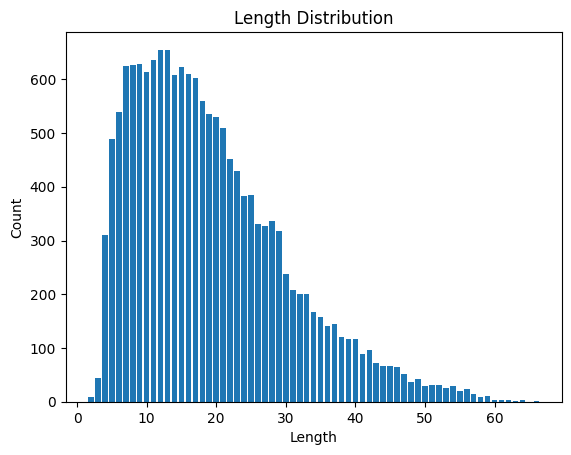

In [8]:
plot_length_distribution(length_distribution(train_data, print=False))

In [9]:
print_distribution(label_distribution(train_data, print=False), is_length=False)

sadness: 4666
anger: 2159
love: 1304
surprise: 572
fear: 1937
joy: 5362


#### Ex 2. Inspecting the Data
Given the 4 functions we provided above :
- Print out the length distribution
- Print out the labels distribution
- Plot the the length distribution

In [ ]:
## Above ##

## Section 3 - MLP network for binary sentiment classification in PyTorch

### Define MLP network

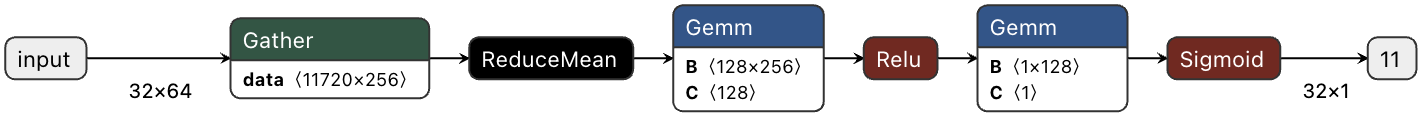

#### Ex 3. Specify a Multi-Layer Perceptron class called BinarySentMLP such that:
- it is a subclass of the nn.Module class
- it includes an embedding layer, and two linear layers
- mean pooling is applied to the embedding layer
- the result of the mean pooling is passed first thru a relu activation and next to a sigmoid
- the output of the sigmoid activation is the output of the network

You can find some help [here](01D_pytorch.ipynb)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a simple MLP for binary sentiment classification

## YOUR CODE HERE ##
class BinarySentMLP(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # embedding layer
        embedded = self.embedding(x)

        # pooling layer
        pooled = embedded.mean(dim=1)
        
        # linear layer 1
        hidden = F.relu(self.fc1(pooled))
        
        # linear layer 2
        output = torch.sigmoid(self.fc2(hidden))
        
        return output


### Data pre-processing for binary classification

The dataset uses 6 labels. We only keep those instances with label 0 (sadness) or 1 (joy) to reduce the task to a binary classification task.

In [10]:
def filter_joy_sadness_dataset(dataset):
    # Keep only examples with label 0 or 1 (sadness or joy)
    return dataset.filter(lambda example: example["label"] in [0, 1])

#### Ex4. Creating train/dev/test data for binary classification
Using the above function, create train/dev/test data for the binary classifier. Call these new datasets `binary_emo_data_train`, `binary_emo_data_val` and `binary_emo_data_test`

In [12]:
## YOUR CODE HERE
binary_emo_data_train = filter_joy_sadness_dataset(train_data)
binary_emo_data_val = filter_joy_sadness_dataset(dev_data)
binary_emo_data_test = filter_joy_sadness_dataset(test_data)


Filter: 100%|██████████| 2000/2000 [00:00<00:00, 109917.95 examples/s]


## Text pre-processing pipeline
Remember that the input to a NN is a tensor. Hence we must process the dataset texts into tensors. 
This involves the following steps:
- Tokenising each text
- Creating the vocabulary i.e., the set of tokens that occur in the dataset to which we add two special symbols "<pad>" and "<unk>"
- Mapping each token in an input text to its index (the mapping is defined when constructing the vocabulary)
- Creating batches from the processed instances using padding to have all instances of the same length

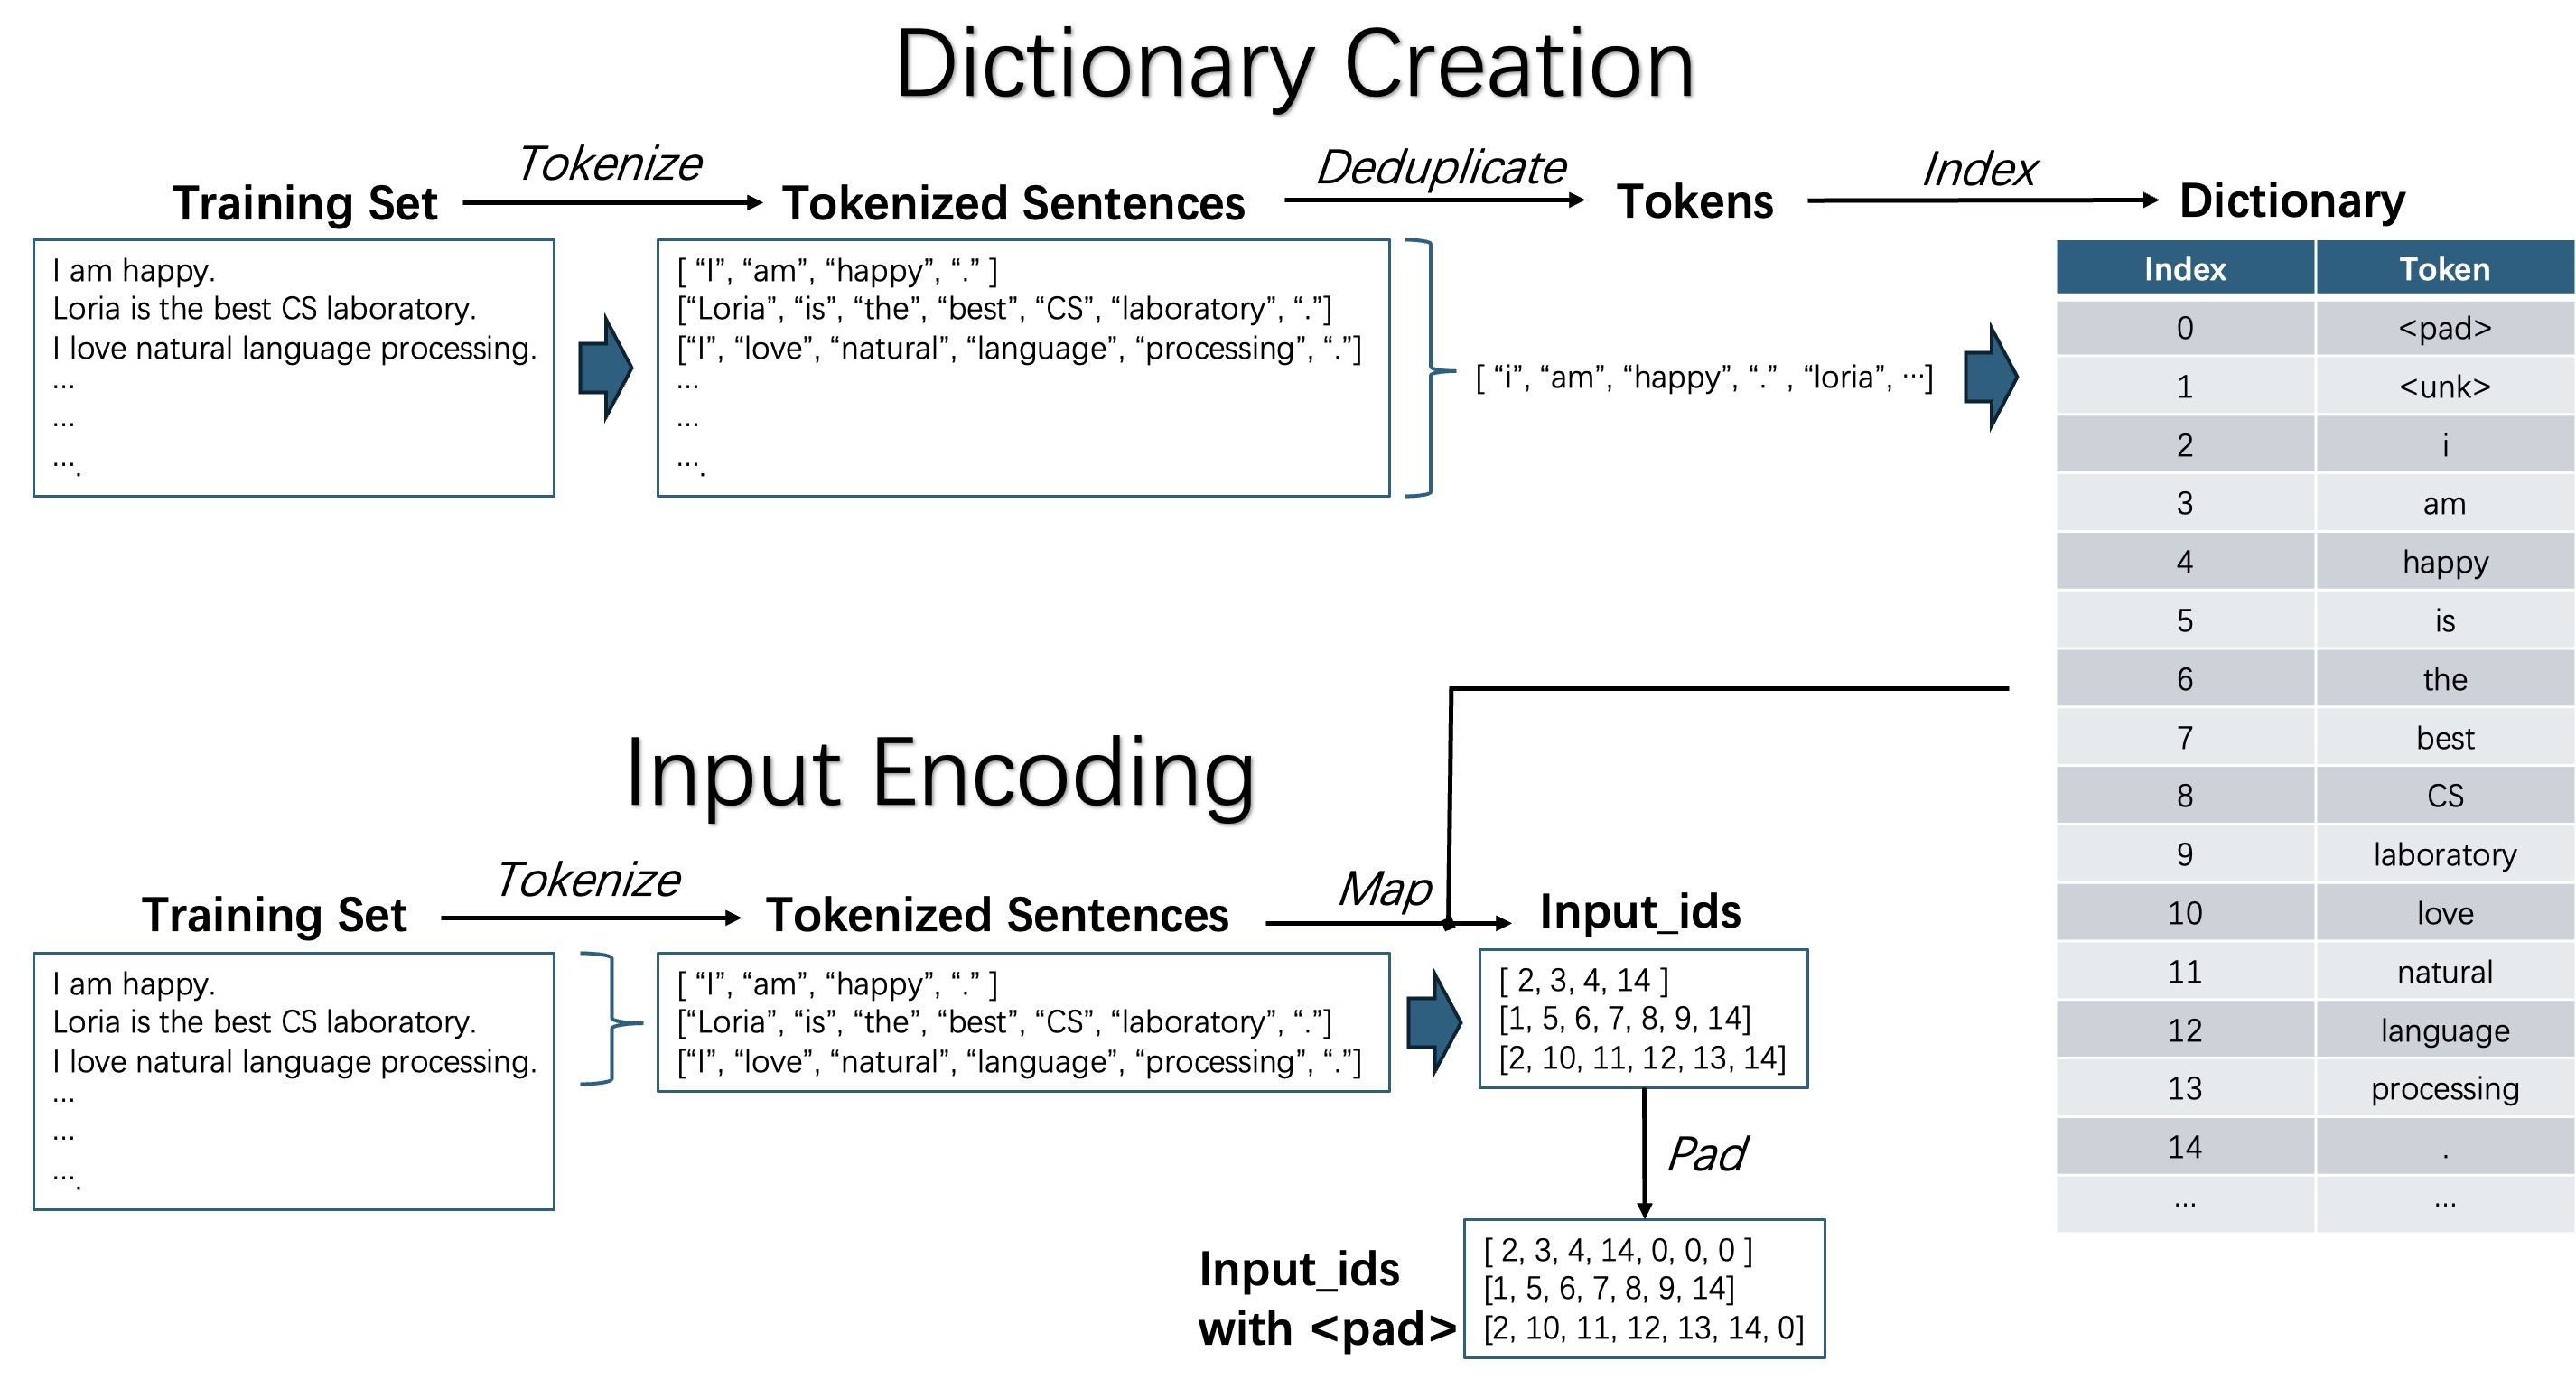

In [13]:
import torch
import nltk
from nltk.tokenize import word_tokenize
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab")


# 1. Tokenize function
def tokenize(text):
    return word_tokenize(text.lower())

# 2. Create vocab (vocabulary corpus)
def build_vocab(dataset, min_freq=1, specials=["<pad>", "<unk>"]):
    counter = Counter()
    for example in tqdm(dataset, leave=False, desc='Creating Corpus'):
        tokens = tokenize(example["text"])
        counter.update(tokens)

    # Sort by frequency, built a map from token to index
    vocab = {}
    idx = 0

    for token in specials:
        vocab[token] = idx
        idx += 1

    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = idx
            idx += 1

    return vocab

# Encode text
def encode(example, vocab):
    tokens = tokenize(example["text"])
    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]
    return {"input_ids": ids, "label": example["label"]}

# This function is used to fit in batch training
# Here, we adopt a dynamic padding strategy, where all sentences are padded to the length of the longest one in the batch.
def collate_batch(batch, pad_index):
    input_ids = [torch.tensor(x["input_ids"]) for x in batch]
    labels = torch.tensor([x["label"] for x in batch])
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=pad_index)
    return {"input_ids": input_ids_padded, "labels": labels}

In [ ]:
#### Ex5. Using the function provided above:
"""
- Build the vocabulary from the training set
- Encode each dataset split ; name the encoded splits `train_dataset`, `val_dataset` and `test_dataset`
- Use the `DataLoader` method to create batches using the `collate_batch` method we provided
"""

In [14]:
binary_emo_data_train

Dataset({
    features: ['text', 'label'],
    num_rows: 10028
})

In [15]:
from torch.utils.data import DataLoader

In [18]:
# Build vocab from the training set
## YOUR CODE HERE 

tr_vocab = build_vocab(binary_emo_data_train, min_freq=4, specials=["<pad>", "<unk>"])

# Encode datasets
## YOUR CODE HERE 

# Convert dataset to dataloader
## YOUR CODE HERE 
train_loader = DataLoader(binary_emo_data_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(binary_emo_data_val, batch_size=32, shuffle=False)
test_loader = DataLoader(binary_emo_data_test, batch_size=32, shuffle=False)

In [ ]:

# the TensorDataset is a ready to use class to represent your data as list of tensors. 
# Note that input_features and labels must match on the length of the first dimension
# # (Same number of instances and of labels)
# train_set = TensorDataset(X_train, Y_train)
# valid_set = TensorDataset(X_valid, Y_valid)
# # DataLoader shuffles, batches and loads  the data in parallel using multiprocessing workers
# from torch.utils.data import TensorDataset, DataLoader

#### Ex6. Print out the size of the vocabulary

In [ ]:
## YOUR CODE HERE 

The Vocab Size is 11720


In [20]:
len(tr_vocab)

3002

### Define MLP Trainer

In [21]:
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

class BinarySentMLPTrainer:
    def __init__(self, model, optimizer, criterion, train_loader, val_loader):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Load model and encoder on gpu
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def train(self, num_epochs):
        train_losses, train_accs = [], []
        val_losses, val_accs = [], []
        for epoch in tqdm(range(num_epochs), desc="Train Epoch"):
            self.model.train()
            total_loss = 0
            for batch in tqdm(self.train_loader, leave=False, desc="Train Batch"):
                # Move data to gpu
                batch = {k: v.to(self.device) for k, v in batch.items()}

                input_ids = batch["input_ids"]
                labels = batch["labels"]

                # Convert input sentences into embedding via encoder
                self.optimizer.zero_grad()
                outputs = self.model(input_ids)
                loss = self.criterion(outputs, labels.unsqueeze(1).float())
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            # Epoch done: evaluate
            train_loss, train_acc = self.evaluate(self.train_loader)
            val_loss, val_acc = self.evaluate(self.val_loader)
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(val_loss)
            val_accs.append(val_acc)
            print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
        # return train_losses, train_accs, val_losses, val_accs

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(dataloader, leave=False, desc="Eval Epoch"):
                # Move data to gpu
                batch = {k: v.to(self.device) for k, v in batch.items()}

                input_ids = batch["input_ids"]
                labels = batch["labels"]

                # Convert input sentences into embedding via encoder
                with torch.no_grad():
                    outputs = self.model(input_ids)
                    loss = self.criterion(outputs, labels.unsqueeze(1).float())
                    total_loss += loss.item()

                predicted = (outputs > 0.5).float()
                correct += (predicted == labels.unsqueeze(1).float()).sum().item()
                total += labels.size(0)
        return total_loss / len(dataloader), correct / total


### Define Hyper-parameters

#### Ex7. Specifying a model and setting training hyperparameters
- In the code below, specify the missing values marked by `???`

In [22]:
## instantiate a mlp model
vocab_size = len(tr_vocab)
embedding_dim = 256
mlp_model = BinarySentMLP(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_dim=128)

## define hyperparameters for mlp model training
num_epochs = 5
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.001)
criterion = nn.BCELoss()


In [23]:
## instantiate a binary sentiment trainer
binary_trainer = BinarySentMLPTrainer(model=mlp_model, optimizer=optimizer, criterion=criterion, train_loader=train_loader, val_loader=valid_loader)

#### Ex8. Train the model (use the train method defined above)

In [33]:
%pip install --upgrade pip

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


In [34]:
%pip install --upgrade tqdm ipywidgets jupyter

Note: you may need to restart the kernel to use updated packages.


In [38]:
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console console.exe dejavu dejavu.exe events events.exe
execute execute.exe kernel kernel.exe kernelspec kernelspec.exe lab lab.exe
labextension labextension.exe labhub labhub.exe migrate migrate.exe nbconvert
nbconvert.exe notebook notebook.exe qtconsole-script.py qtconsol

In [36]:
### YOUR CODE HERE
binary_trainer.train(num_epochs=num_epochs)
# Evaluate the model on the test set

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

#### Ex9. Evaluate the binary model on the test set and print out the loss and accuracy

In [ ]:
## YOUR CODE HERE
test_loss, test_acc = binary_trainer.evaluate(test_loader)

Eval Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.1251, Acc: 0.9600


This function is only for network visulization. You can ignore this block as you like.

In [ ]:
!pip install onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 98.5 MB/s eta 0:00:00


In [ ]:
for batch in train_dataloader:
    dummy_input = {k: v.to(torch.device("cuda")) for k, v in batch.items()}
    break

torch.onnx.export(mlp_model, dummy_input["input_ids"], "binarymodel.onnx")

## Section 4 (PROVIDED) - From Binary to Multi-Class classification

In this section, we extend our task to **multi-class sentiment classification** using all six sentiment categories.  
Our objective is now to **predict the exact sentiment** (one out of six possible classes) for each input text.

---

**🔁 Recap (Binary Classification):**  
In binary classification, we used a **sigmoid layer** at the end of the MLP to map the output to a probability between 0 and 1, representing the likelihood of the input belonging to the positive class.

---

**🔄 Extending to Multi-class Classification:**  
Instead of producing a single probability score, the model now outputs **one score per sentiment category**.  
This results in **six output scores**, each representing the probability that the input belongs to a specific sentiment class.  
To determine the final prediction, we simply choose the class with the **highest predicted probability** (i.e., apply `argmax` over the output).


### Define MLP network

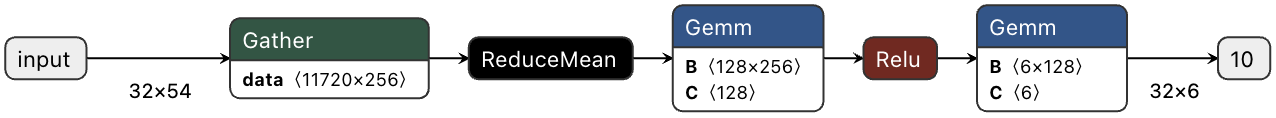

In [ ]:
class MultiSentMLP(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes=6):
        super(MultiSentMLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  # Word embedding layer
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids) # Shape: (Batch Size, Sentence Length, Embedding Dimension)
        pooled = embedded.mean(dim=1)       # Average along the sentence length dimension
        x = F.relu(self.fc1(pooled))
        # No need for activation function here (softmax)
        # it is already included in the CrossEntropyLoss computation
        x = self.fc2(x)
        return x

### Data pre-processing for multi-class classification
Since we are going to all categories, there is no need for sentiment category filtering.

We start from the tokenization.

In [ ]:
emo_data_train

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [ ]:
# Build vocab from the training set
multi_vocab = build_vocab(emo_data_train)
print(f"The created vocabulary has {len(multi_vocab)} tokens.")

# Encode datasets
train_dataset = [encode(ex, vocab) for ex in emo_data_train]
val_dataset = [encode(ex, vocab) for ex in emo_data_val]
test_dataset = [encode(ex, vocab) for ex in emo_data_test]

# Convert dataset to dataloader
pad_index = vocab["<pad>"]
train_dataloader = DataLoader(train_dataset, batch_size=32, collate_fn=lambda x: collate_batch(x, pad_index))
val_dataloader = DataLoader(val_dataset, batch_size=32, collate_fn=lambda x: collate_batch(x, pad_index))
test_dataloader = DataLoader(test_dataset, batch_size=32, collate_fn=lambda x: collate_batch(x, pad_index))

Creating Corpus:   0%|          | 0/16000 [00:00<?, ?it/s]

The created vocabulary has 15212 tokens.


### Define MLP Trainer

In [ ]:
class MultiSentMLPTrainer:
    def __init__(self, model, optimizer, criterion, train_loader, val_loader):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Load model and encoder on GPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def train(self, num_epochs):
        train_losses, train_accs = [], []
        val_losses, val_accs = [], []
        for epoch in tqdm(range(num_epochs), desc="Train Epoch"):
            self.model.train()
            total_loss = 0
            correct = 0
            total = 0

            for batch in tqdm(self.train_loader, leave=False, desc="Train Batch"):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                input_ids = batch["input_ids"]
                labels = batch["labels"]  # shape: (B,), dtype: int64

                self.optimizer.zero_grad()
                outputs = self.model(input_ids)  # shape: (B, num_classes)
                loss = self.criterion(outputs, labels)  # ✅ CrossEntropyLoss expects raw logits + int labels

                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()

                # Accuracy
                predicted = torch.argmax(outputs, dim=1)  # ✅ Multi-class prediction
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            train_loss = total_loss / len(self.train_loader)
            train_acc = correct / total

            # Evaluate on validation set
            val_loss, val_acc = self.evaluate(self.val_loader)
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            val_losses.append(val_loss)
            val_accs.append(val_acc)

            print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in tqdm(dataloader, leave=False, desc="Eval Epoch"):
                batch = {k: v.to(self.device) for k, v in batch.items()}
                input_ids = batch["input_ids"]
                labels = batch["labels"]

                with torch.no_grad():
                    outputs = self.model(input_ids)
                    loss = self.criterion(outputs, labels)  # ✅

                total_loss += loss.item()
                predicted = torch.argmax(outputs, dim=1)  # ✅ Multi-class
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        return total_loss / len(dataloader), correct / total


### Define Hyper-parameter

In [ ]:
## instantiate a mlp model
vocab_size = len(vocab)
embedding_dim = 256
mlp_model = MultiSentMLP(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_dim=128)

## define hyperparameters for mlp model training
num_epochs = 5
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

## instantiate a multi-class sentiment trainer
multi_trainer = MultiSentMLPTrainer(mlp_model, optimizer, criterion, train_dataloader, val_dataloader)


### Train MLP with per epoch eval

In [ ]:
multi_trainer.train(num_epochs)

Train Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Train Batch:   0%|          | 0/500 [00:00<?, ?it/s]

Eval Epoch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.4873, Acc: 0.3620 | Val Loss: 1.7233, Acc: 0.2945


Train Batch:   0%|          | 0/500 [00:00<?, ?it/s]

...

Eval Epoch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.6266, Acc: 0.7678 | Val Loss: 2.2246, Acc: 0.5570


Train Batch:   0%|          | 0/500 [00:00<?, ?it/s]

Eval Epoch:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 0.4766, Acc: 0.8321 | Val Loss: 2.3398, Acc: 0.5760


In [ ]:
# Evaluate the trained model on test set
test_loss, test_acc = multi_trainer.evaluate(test_dataloader)
print(f"Train Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

Eval Epoch:   0%|          | 0/63 [00:00<?, ?it/s]

Train Loss: 2.4672, Acc: 0.5720


In [ ]:
for batch in train_dataloader:
    dummy_input = {k: v.to(torch.device("cuda")) for k, v in batch.items()}
    break

torch.onnx.export(mlp_model, dummy_input["input_ids"], "multimodel.onnx")